In [5]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

analysis_path = r"C:\Projects\Olist\data\analysis"
output_path = r"C:\Projects\Olist\images"
os.makedirs(output_path, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "sans-serif"

# Load all CSVs
top_categories = pd.read_csv(f"{analysis_path}/top_categories.csv")
delivery_state = pd.read_csv(f"{analysis_path}/delivery_by_state.csv")
late_impact = pd.read_csv(f"{analysis_path}/late_delivery_impact.csv")
rfm = pd.read_csv(f"{analysis_path}/rfm_segmentation.csv")
sellers = pd.read_csv(f"{analysis_path}/seller_performance.csv")
payments = pd.read_csv(f"{analysis_path}/payment_methods.csv")
basket = pd.read_csv(f"{analysis_path}/basket_size.csv")
repeat = pd.read_csv(f"{analysis_path}/repeat_customers.csv")
weekday = pd.read_csv(f"{analysis_path}/revenue_by_weekday.csv")

print("All files loaded successfully")

All files loaded successfully


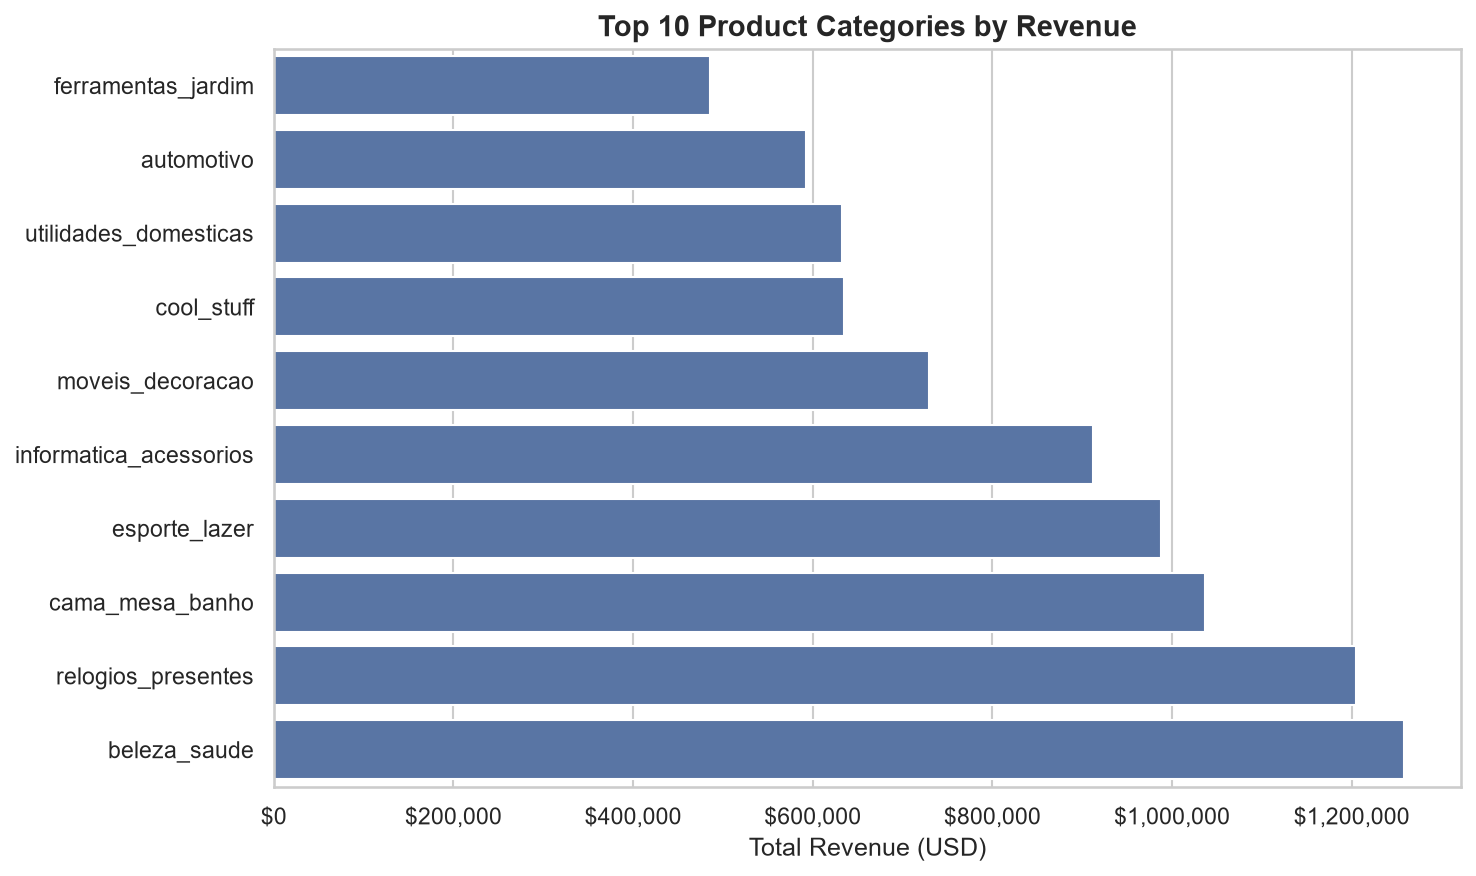

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_categories.sort_values("total_revenue"), 
            x="total_revenue", y="category", ax=ax, color="#4C72B0")
ax.set_title("Top 10 Product Categories by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue (USD)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig(f"{output_path}/top_categories.png")
plt.show()

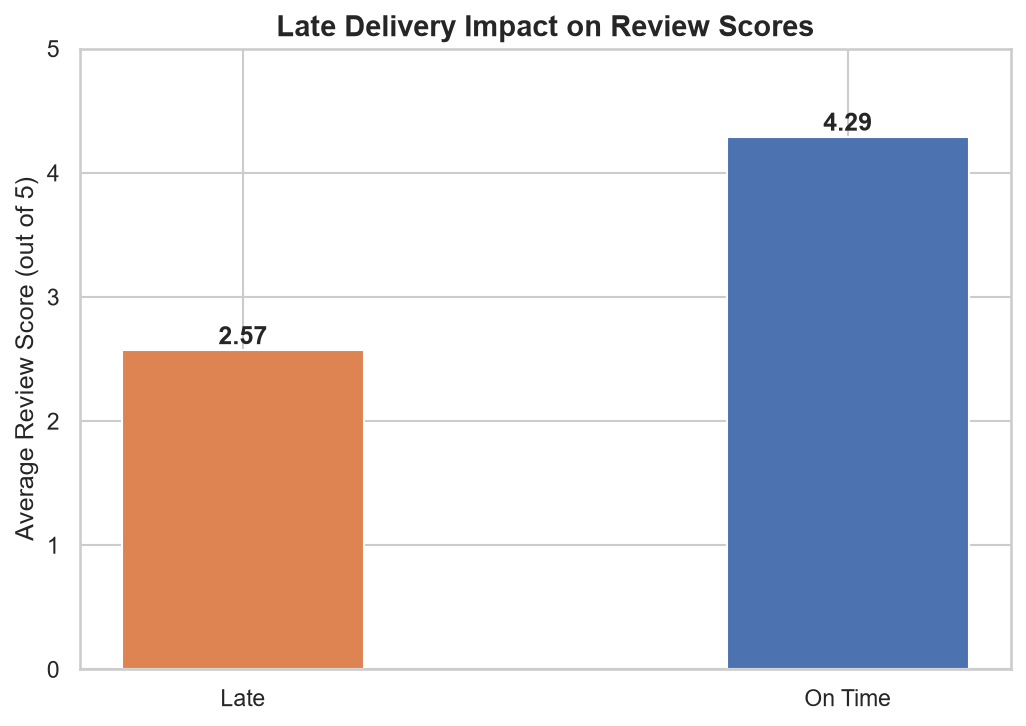

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#DD8452", "#4C72B0"]
bars = ax.bar(late_impact["delivery_status"], late_impact["avg_review_score"], color=colors, width=0.4)
ax.set_title("Late Delivery Impact on Review Scores", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Review Score (out of 5)")
ax.set_ylim(0, 5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.2f}", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{output_path}/late_delivery_impact.png")
plt.show()

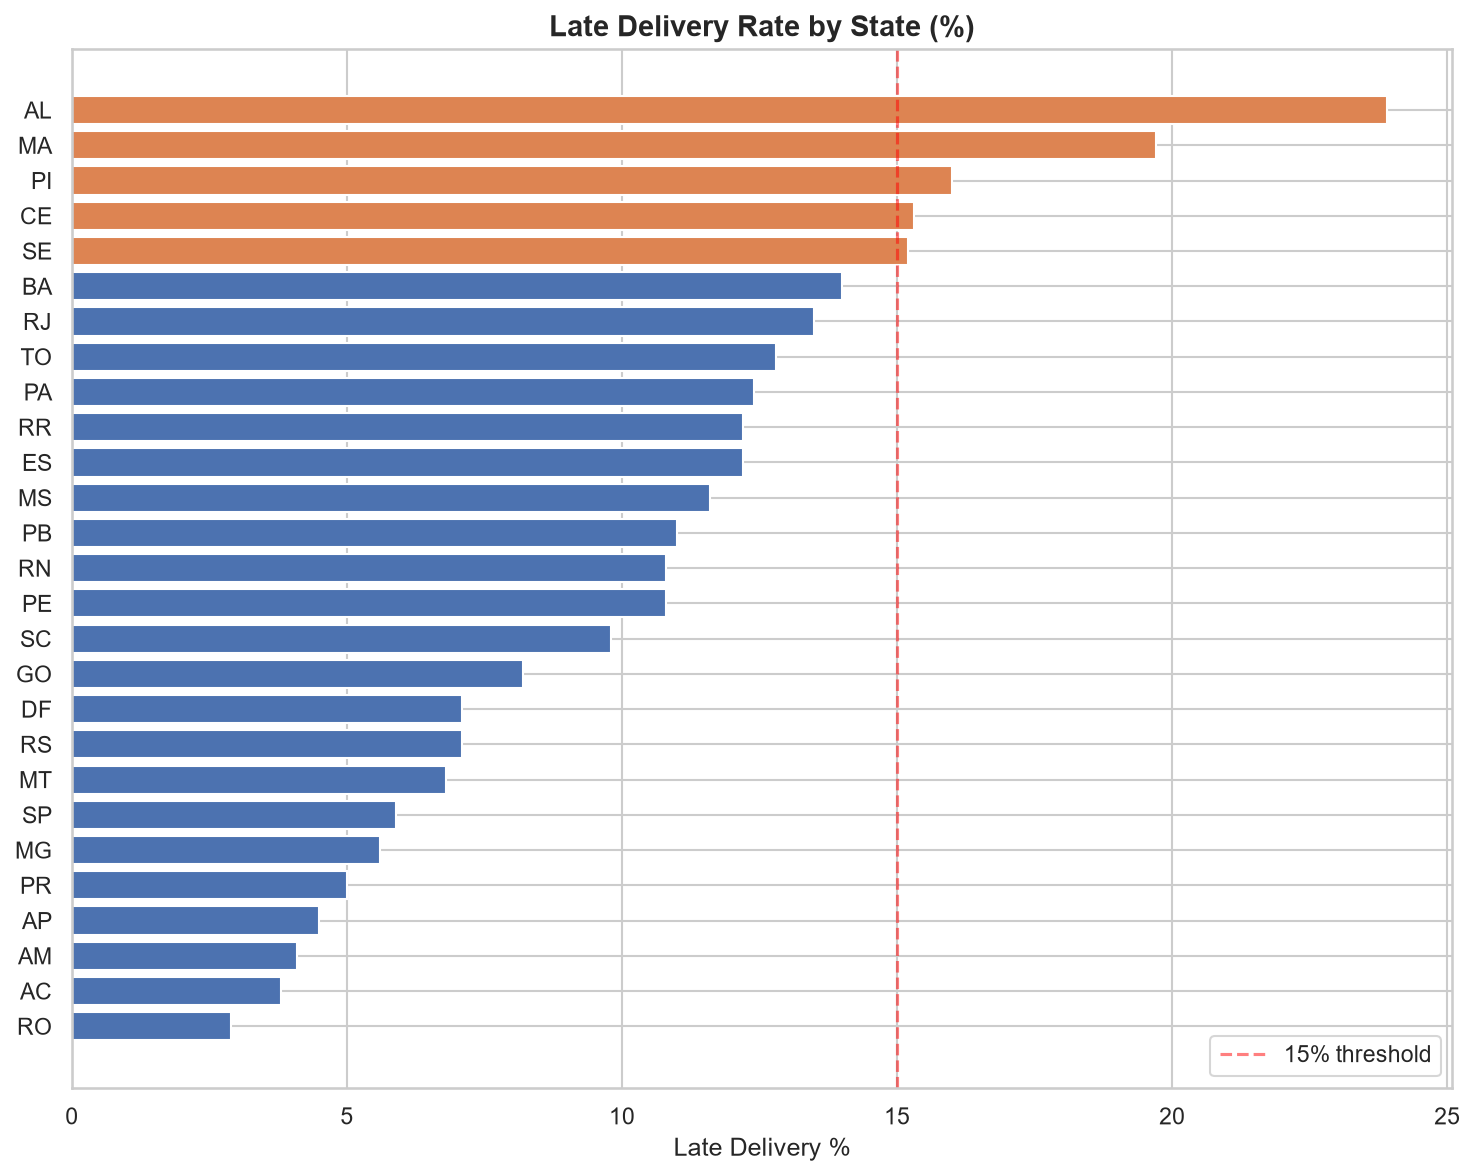

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
delivery_sorted = delivery_state.sort_values("late_delivery_pct", ascending=True)
colors = ["#DD8452" if x > 15 else "#4C72B0" for x in delivery_sorted["late_delivery_pct"]]
ax.barh(delivery_sorted["state"], delivery_sorted["late_delivery_pct"], color=colors)
ax.set_title("Late Delivery Rate by State (%)", fontsize=14, fontweight="bold")
ax.set_xlabel("Late Delivery %")
ax.axvline(x=15, color="red", linestyle="--", alpha=0.5, label="15% threshold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{output_path}/late_delivery_by_state.png")
plt.show()

C:\Users\harba\AppData\Local\Temp\ipykernel_31536\3129825474.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rfm, x="segment", y="customer_count", ax=axes[0], palette="muted")
C:\Users\harba\AppData\Local\Temp\ipykernel_31536\3129825474.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rfm, x="segment", y="avg_spend", ax=axes[1], palette="muted")


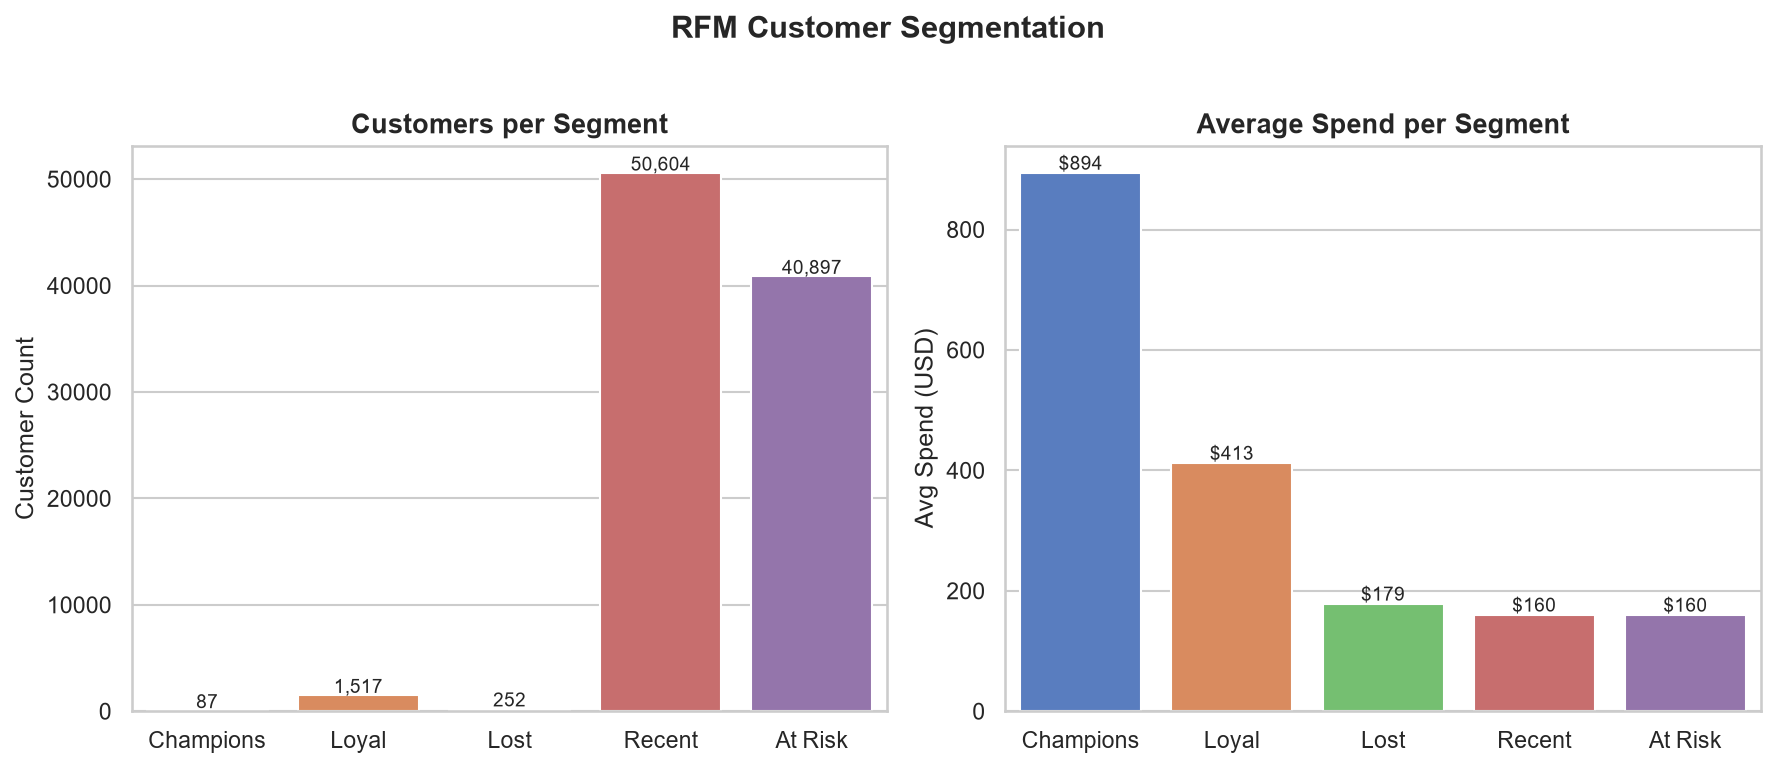

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Customer count
sns.barplot(data=rfm, x="segment", y="customer_count", ax=axes[0], palette="muted")
axes[0].set_title("Customers per Segment", fontsize=13, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Customer Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", 
                     (p.get_x() + p.get_width()/2, p.get_height() + 200),
                     ha="center", fontsize=9)

# Avg spend
sns.barplot(data=rfm, x="segment", y="avg_spend", ax=axes[1], palette="muted")
axes[1].set_title("Average Spend per Segment", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg Spend (USD)")
for p in axes[1].patches:
    axes[1].annotate(f"${p.get_height():,.0f}", 
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha="center", fontsize=9)

plt.suptitle("RFM Customer Segmentation", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{output_path}/rfm_segmentation.png", bbox_inches="tight")
plt.show()

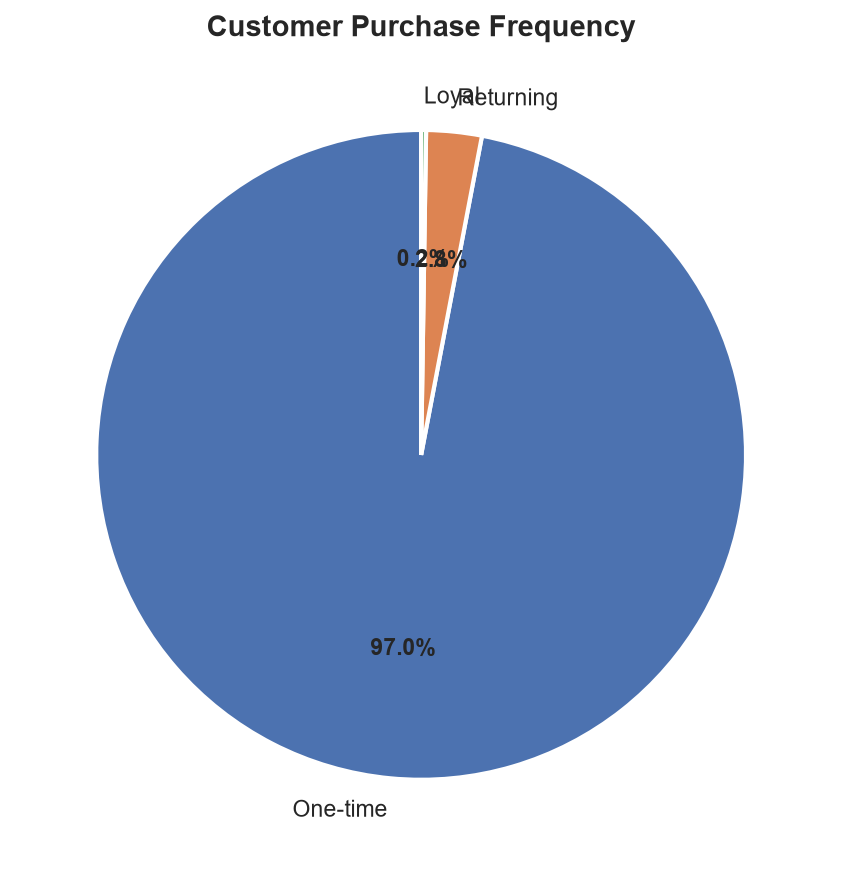

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
colors = ["#4C72B0", "#DD8452", "#55A868"]
wedges, texts, autotexts = ax.pie(
    repeat["customer_count"],
    labels=repeat["customer_type"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight("bold")
ax.set_title("Customer Purchase Frequency", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{output_path}/repeat_customers.png")
plt.show()

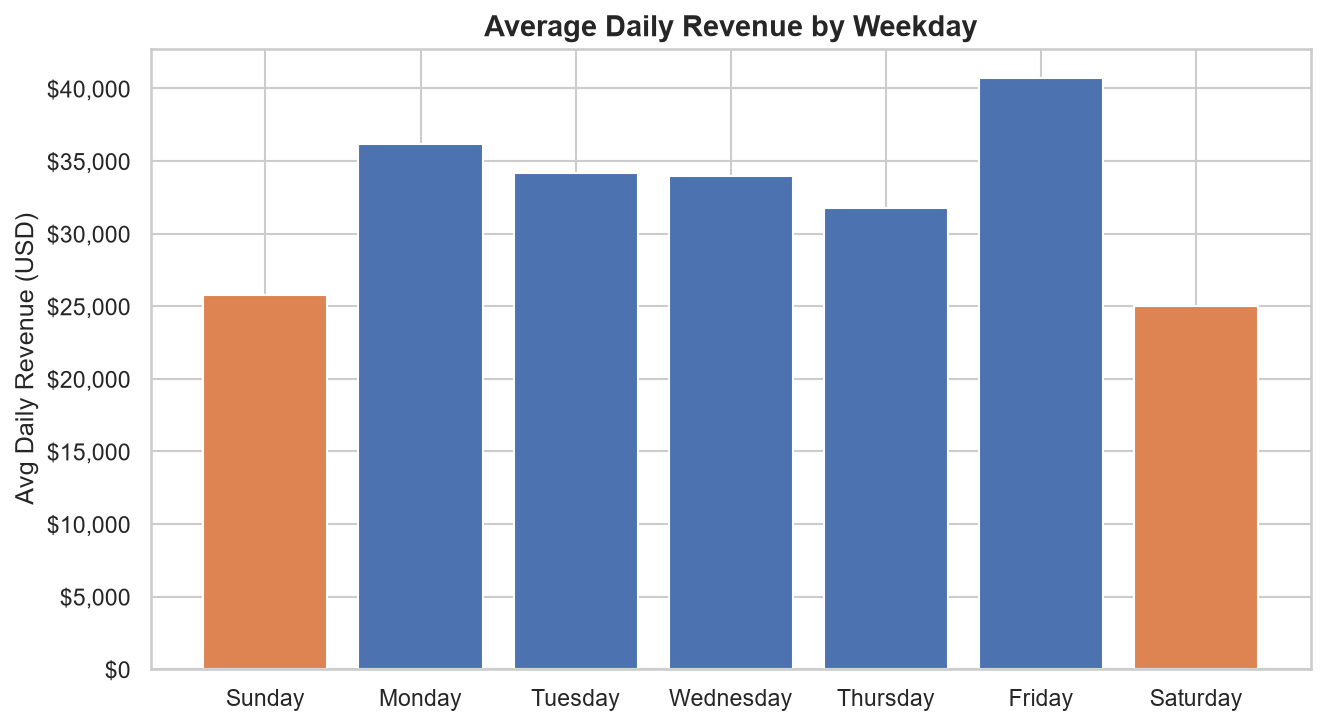

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
weekday_sorted = weekday.sort_values("day_num")
colors = ["#DD8452" if d in [0, 6] else "#4C72B0" for d in weekday_sorted["day_num"]]
ax.bar(weekday_sorted["weekday"].str.strip(), weekday_sorted["avg_daily_revenue"], color=colors)
ax.set_title("Average Daily Revenue by Weekday", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Avg Daily Revenue (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig(f"{output_path}/revenue_by_weekday.png")
plt.show()